# kin_05 — Non-lick movements

Do the lickometer and video-derived movement streams describe the same set of events —
and what are the movements that aren't licks?

`kin_02` shows that lick latency grows with cue-response movement ordinal, and that the
Δt de-shift only partially collapses the k=1/k=2 distributions onto each other (§10's
open question). The residual is attributed to *further* covert preparatory movements —
movements the tongue makes that never trigger the lickometer. This notebook establishes
that those movements are real, structured events, not lickometer noise, before anything
downstream treats them as such.

**This is a definitional question, not a QC filter.** Lickometer agreement, confidence,
and movement duration are not valid noise criteria — QC noise means confident
misdetection of the wrong body part, which is `kin_00`'s job. Nothing here removes or
flags data; every movement, lick-associated or not, stays in the pool.

**Pipeline:**
1. Load `all_tongue_movements` parquet
2. Three-way correspondence tally: licks without movements, movements with >1 lick,
   movements without licks
3. Licks without movements (Code Ocean only)
4. Movements with multiple licks
5. Kinematic profile of non-lick movements: duration, total distance
6. Per-trial structure: how many non-lick movements per trial, and do they track lick
   movements?
7. Preparatory timing: how often does a non-lick movement precede the cue-response lick?

## 1. Setup

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from plotstyle import apply_style, PALETTE, style_ax, save_fig
apply_style()

In [2]:
if Path("/root/capsule").exists():
    ENV       = "codeocean"
    SCRATCH   = Path("/root/capsule/scratch")
    FOR_LOCAL = SCRATCH / "for_local"
else:
    ENV       = "local"
    FOR_LOCAL = Path("/Users/mib/Documents/Code/kinematics_analysis/data/for_local")
    SCRATCH   = FOR_LOCAL.parent

IS_CO    = ENV == "codeocean"
FIG_DIR  = SCRATCH / "figures" / "kin_05_nonlick_movements"
SAVE_FIG = False
print(f"ENV={ENV}")

ENV=local


## 2. Load data

In [3]:
if ENV == "codeocean":
    movements_path = SCRATCH / "all_tongue_movements_04022026" / "all_tongue_movements_04022026.parquet"
else:
    movements_path = FOR_LOCAL / "all_tongue_movements_04022026.parquet"

all_tongue_movements = pd.read_parquet(movements_path)
print("Shape:", all_tongue_movements.shape)
print("Sessions:", all_tongue_movements["session"].nunique())


def coerce_bool(series):
    """Coerce an object-dtype True/False/None column to real booleans.

    Plain ``astype(bool)`` on an object column turns any non-empty string
    (including the string "False") into True. This instead treats only
    True/1/"True" as true and everything else, including None, as false.

    Parameters
    ----------
    series : pandas.Series
        Object-dtype column holding True/False/None (or their 1/0/string
        equivalents).

    Returns
    -------
    pandas.Series
        Boolean-dtype series.
    """
    return series.isin([True, 1, "True"])


df = all_tongue_movements.copy()
df["cue_response"] = coerce_bool(df["cue_response"])
# has_lick is already real bool; movement_before_cue_response is pandas nullable
# "boolean" (True/False/<NA>) — leave <NA> as missing rather than coercing, each
# section below decides how to treat it.

Shape: (246359, 49)
Sessions: 44


## 3. Three-way correspondence tally

The lickometer (licks) and the video-derived movement stream (movements) are two
independent detectors of the same behavior. They disagree in three ways:

**a. Licks without movements** — a lickometer contact with no matching video movement.
Needs `nearest_movement_id`, assigned per-session onto `nwb.df_licks` when the video
movement stream is matched to lick timestamps. That column is **not in the pooled
parquet** (see `TODO.md`'s data-availability note) — it only exists in the per-session
`nwb_df_licks.parquet` written to `/root/capsule/scratch` on Code Ocean. Verified against
`all_tongue_movements_04022026.parquet`'s 49 columns below: `nearest_movement_id` is
absent. So **part (a) is Code Ocean-only**, unlike the pooled parts (b) and (c) — see
§4.

**b. Movements with more than one lick** — `lick_count > 1`, pooled-safe.

**c. Movements without any licks** — `has_lick == False`, pooled-safe. This is the
population the rest of the notebook is about.

In [4]:
print("nearest_movement_id in pooled columns:",
      "nearest_movement_id" in all_tongue_movements.columns)

# b. Movements with more than one lick (pooled: lick_count is a movement-level column)
multi_lick_movs = df[df["lick_count"] > 1]
total_licked_movs = df["has_lick"].sum()
pct_multi = len(multi_lick_movs) / total_licked_movs * 100
print(f"\nMovements with >1 lick: {len(multi_lick_movs):,} of {total_licked_movs:,} "
      f"lick-associated movements ({pct_multi:.2f}%)")

# c. Movements without any licks (pooled: has_lick is a movement-level column)
movements_without_licks = df[df["has_lick"] == False]
total_movs = len(df)
pct_no_lick = len(movements_without_licks) / total_movs * 100
print(f"Movements without licks: {len(movements_without_licks):,} of {total_movs:,} "
      f"total movements ({pct_no_lick:.2f}%)")

nearest_movement_id in pooled columns: False

Movements with >1 lick: 8,585 of 151,404 lick-associated movements (5.67%)
Movements without licks: 94,955 of 246,359 total movements (38.54%)


## 4. Licks without movements (Code Ocean only)

Needs per-session `nwb_df_licks.parquet` for `nearest_movement_id`, gated the way
`kin_00` gates its trajectory/video sections. Written but unexecuted locally — the
expected schema:

- `nwb_df_licks.parquet` per session, one row per lick, with a `nearest_movement_id`
  column (NaN when no video movement was matched within tolerance) and a `timestamps`
  column (lick time in session).
- Unmatched licks: `df_licks[df_licks["nearest_movement_id"].isna()]`.
- The source (`tongue_kinematics` cells 37, 39) plots the tongue x-position trace around
  each unmatched lick — singly and in sequences — to check by eye whether these are real
  contacts the video missed or lickometer artifacts (e.g. spout jostling).

In [5]:
if not IS_CO:
    print("[skip] Licks without movements: Code Ocean only (needs per-session nwb_df_licks.parquet).")
else:
    import glob

    licks_without_movement_frames = []
    for licks_path in sorted(glob.glob(str(SCRATCH / "session_analysis_mlk" / "*" / "nwb_df_licks.parquet"))):
        session_licks = pd.read_parquet(licks_path)
        unmatched = session_licks[session_licks["nearest_movement_id"].isna()].copy()
        unmatched["session"] = Path(licks_path).parents[0].name
        licks_without_movement_frames.append(unmatched)

    licks_without_movement = pd.concat(licks_without_movement_frames, ignore_index=True)
    print(f"Licks without a matched movement: {len(licks_without_movement):,}")

    # Tongue x-position trace around a few example unmatched licks, and around
    # unmatched licks that occur in sequences (>=2 within 0.5 s of each other) —
    # ports tongue_kinematics cells 37, 39. Needs per-frame tongue_kins.parquet
    # per session (same asset kin_02 §11 uses), joined on session + time window.
    example_licks = licks_without_movement.head(3)
    for _, lick in example_licks.iterrows():
        kins_path = SCRATCH / "session_analysis_mlk" / lick["session"] / "intermediate_data" / "tongue_kins.parquet"
        if not kins_path.exists():
            continue
        tongue_kins = pd.read_parquet(kins_path)
        t0, t1 = lick["timestamps"] - 0.5, lick["timestamps"] + 0.5
        window = tongue_kins[(tongue_kins["time_in_session"] >= t0) & (tongue_kins["time_in_session"] <= t1)]

        fig, ax = plt.subplots(figsize=(6, 3))
        ax.plot(window["time_in_session"], window["x"], color=PALETTE["all"])
        ax.axvline(lick["timestamps"], color=PALETTE["pos"], ls="--", label="Unmatched lick")
        ax.set(xlabel="Time in session (s)", ylabel="Tongue x-position (pix)",
               title=f"{lick['session']} — unmatched lick at t={lick['timestamps']:.2f}s")
        ax.legend()
        style_ax(ax)
        plt.tight_layout()
        save_fig(fig, f"unmatched_lick_{lick['session']}_{lick['timestamps']:.2f}", fig_dir=FIG_DIR, save=SAVE_FIG)
        plt.show()

[skip] Licks without movements: Code Ocean only (needs per-session nwb_df_licks.parquet).


## 5. Movements with multiple licks

From §3b: a small fraction of movements are associated with more than one lickometer
contact — most plausibly rapid re-contacts within a single tongue excursion (e.g. at a
spout edge) rather than two independent movements. How rare, and does the rate vary by
session?

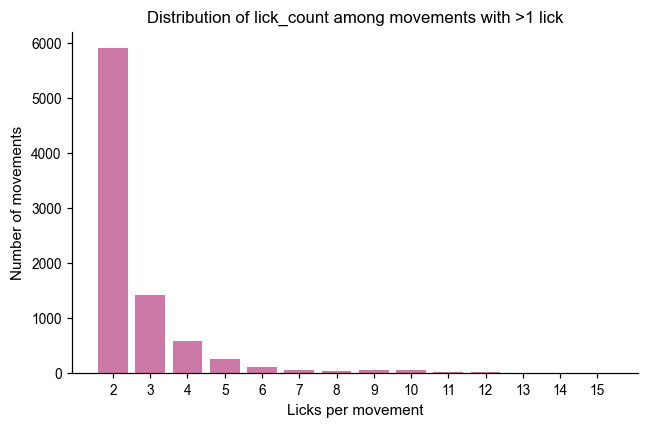

Per-session % of lick-associated movements with >1 lick:
count    44.000000
mean      6.947442
std       7.677276
min       0.028277
25%       1.113746
50%       2.884192
75%      11.490160
max      32.148715
dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = multi_lick_movs["lick_count"].value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color=PALETTE["accent"])
ax.set(xlabel="Licks per movement", ylabel="Number of movements",
       title="Distribution of lick_count among movements with >1 lick")
style_ax(ax)
plt.tight_layout()
save_fig(fig, "multi_lick_count_distribution", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

per_session = df.groupby("session").agg(
    multi_lick=("lick_count", lambda s: (s > 1).sum()),
    lick_assoc=("has_lick", lambda s: (s == True).sum()),
)
per_session_rate = per_session["multi_lick"] / per_session["lick_assoc"].clip(lower=1) * 100
print("Per-session % of lick-associated movements with >1 lick:")
print(per_session_rate.describe())

## 6. Kinematic profile of non-lick movements

`kin_01` §5 already compares lick vs. no-lick movements on the two *outbound-phase*
metrics (`out_peak_velocity`, `out_duration`). This extends the comparison to
whole-movement `duration` and `total_distance` — different columns, not a duplicate —
including the fine-grained sub-50 ms histogram that resolves the bulk of movements,
which sit below the coarse-histogram bin width.

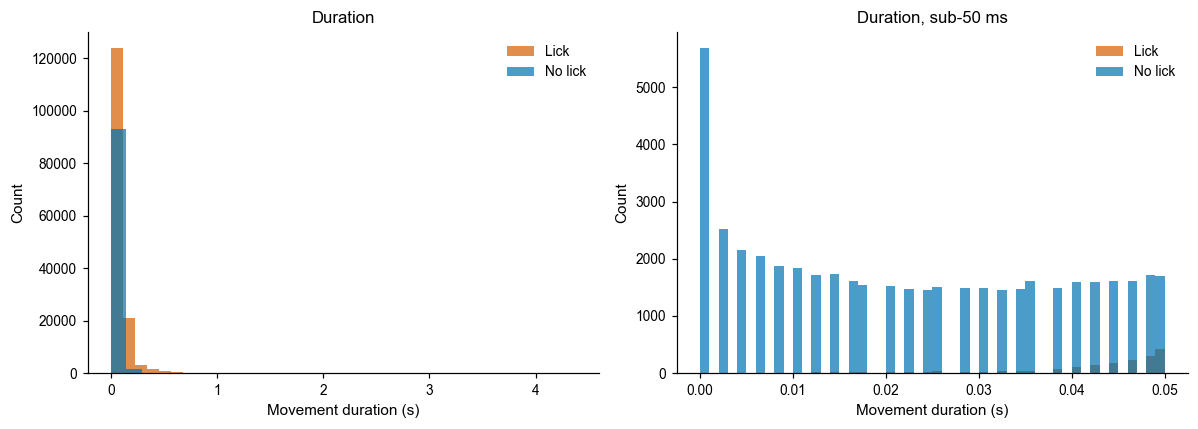

Duration mean — lick: 0.1059s, no-lick: 0.0518s


In [7]:
movements_with_lick = df[df["has_lick"] == True]
movements_without_lick = df[df["has_lick"] == False]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(movements_with_lick["duration"], bins=30, alpha=0.7, color=PALETTE["pos"], label="Lick")
axes[0].hist(movements_without_lick["duration"], bins=30, alpha=0.7, color=PALETTE["neg"], label="No lick")
axes[0].set(xlabel="Movement duration (s)", ylabel="Count", title="Duration")
axes[0].legend()
style_ax(axes[0])

small_bins = np.arange(0, 0.051, 0.001)
axes[1].hist(movements_with_lick["duration"].round(4), bins=small_bins, alpha=0.7, color=PALETTE["pos"], label="Lick")
axes[1].hist(movements_without_lick["duration"].round(4), bins=small_bins, alpha=0.7, color=PALETTE["neg"], label="No lick")
axes[1].set(xlabel="Movement duration (s)", ylabel="Count", title="Duration, sub-50 ms")
axes[1].legend()
style_ax(axes[1])

plt.tight_layout()
save_fig(fig, "duration_lick_vs_nolick", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

print("Duration mean — lick: {:.4f}s, no-lick: {:.4f}s".format(
    movements_with_lick["duration"].mean(), movements_without_lick["duration"].mean()))

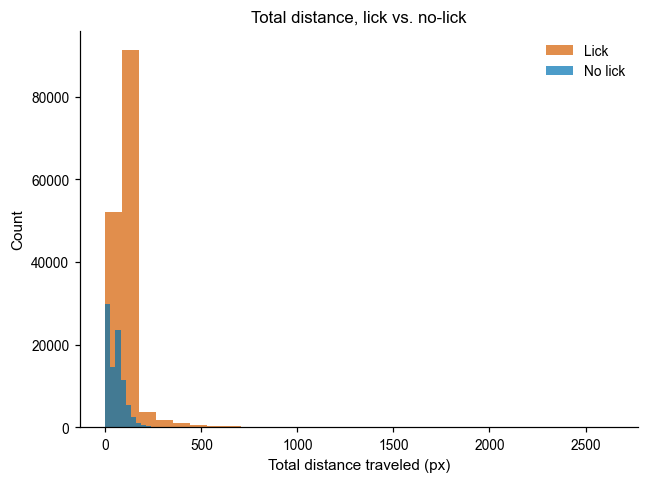

Total distance mean — lick: 111.85px, no-lick: 53.99px


In [8]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(movements_with_lick["total_distance"].dropna(), bins=30, alpha=0.7, color=PALETTE["pos"], label="Lick")
ax.hist(movements_without_lick["total_distance"].dropna(), bins=30, alpha=0.7, color=PALETTE["neg"], label="No lick")
ax.set(xlabel="Total distance traveled (px)", ylabel="Count", title="Total distance, lick vs. no-lick")
ax.legend()
style_ax(ax)
plt.tight_layout()
save_fig(fig, "total_distance_lick_vs_nolick", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

print("Total distance mean — lick: {:.2f}px, no-lick: {:.2f}px".format(
    movements_with_lick["total_distance"].mean(), movements_without_lick["total_distance"].mean()))

## 7. Per-trial structure

How many non-lick movements occur per trial, and does a trial with more lick movements
also tend to have more non-lick movements (both driven by e.g. engagement/arousal), or
are they independent?

`trial` is only unique **within** a session, so this groups by `(session, trial)` — the
source notebook (single-session) grouped by `trial` alone, which would silently pool
across sessions here.

In [9]:
movements = df.dropna(subset=["trial"]).copy()

total_per_trial = movements.groupby(["session", "trial"]).size().rename("total_movements")
lick_per_trial = (
    movements[movements["has_lick"] == True]
    .groupby(["session", "trial"]).size().rename("lick_movements")
)
nonlick_per_trial = (
    movements[movements["has_lick"] != True]
    .groupby(["session", "trial"]).size().rename("nonlick_movements")
)

trial_summary = pd.concat([total_per_trial, lick_per_trial, nonlick_per_trial], axis=1).fillna(0)
trial_summary["percent_nonlick"] = trial_summary["nonlick_movements"] / trial_summary["total_movements"] * 100
print("Trials:", len(trial_summary))
trial_summary.describe()

Trials: 14727


,total_movements,lick_movements,nonlick_movements,percent_nonlick
count,14727.000000,14727.000000,14727.000000,14727.000000
mean,15.085965,9.481564,5.604400,31.905555
std,36.053276,21.178136,18.053359,24.113476
min,1.000000,0.000000,0.000000,0.000000
25%,6.000000,4.000000,1.000000,13.333333
50%,12.000000,7.000000,3.000000,28.571429
75%,19.000000,13.000000,5.000000,46.428571
max,3326.000000,1542.000000,1784.000000,100.000000


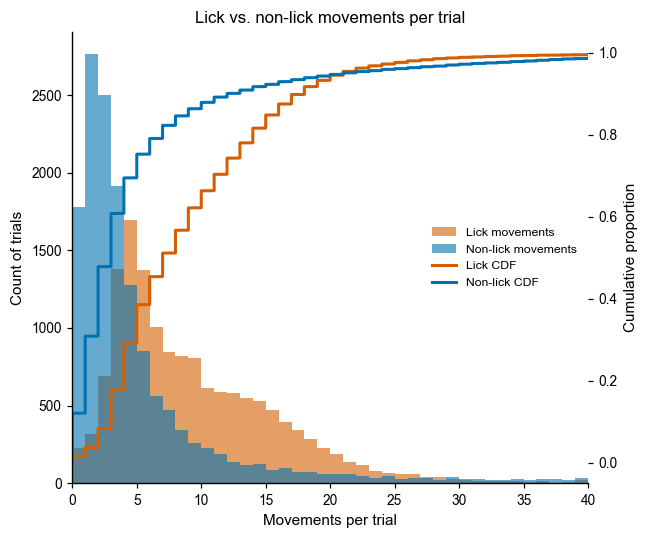

Trials with >40 total movements: 523 of 14727


In [10]:
fig, ax1 = plt.subplots(figsize=(6, 5))
bins = np.arange(0, 41, 1)
ax1.hist(trial_summary["lick_movements"], bins=bins, color=PALETTE["pos"], alpha=0.6, label="Lick movements")
ax1.hist(trial_summary["nonlick_movements"], bins=bins, color=PALETTE["neg"], alpha=0.6, label="Non-lick movements")
ax1.set(xlabel="Movements per trial", ylabel="Count of trials",
        title="Lick vs. non-lick movements per trial")
style_ax(ax1)

ax2 = ax1.twinx()
lick_sorted = np.sort(trial_summary["lick_movements"])
nonlick_sorted = np.sort(trial_summary["nonlick_movements"])
ax2.plot(lick_sorted, np.arange(1, len(lick_sorted) + 1) / len(lick_sorted),
          color=PALETTE["pos"], linewidth=2, label="Lick CDF")
ax2.plot(nonlick_sorted, np.arange(1, len(nonlick_sorted) + 1) / len(nonlick_sorted),
          color=PALETTE["neg"], linewidth=2, label="Non-lick CDF")
ax2.set_ylabel("Cumulative proportion")
ax1.set_xlim(0, 40)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=8)

plt.tight_layout()
save_fig(fig, "movements_per_trial", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

# A handful of trials run far above this range (e.g. the session-final trial can
# absorb every movement after the last recorded go cue); the axis above is clipped
# to the bulk of the distribution for legibility. Nothing is excluded from the
# correlations below.
print("Trials with >40 total movements:", (trial_summary["total_movements"] > 40).sum(),
      "of", len(trial_summary))

Lick vs. non-lick movements per trial: Pearson r = 0.687, p = 0


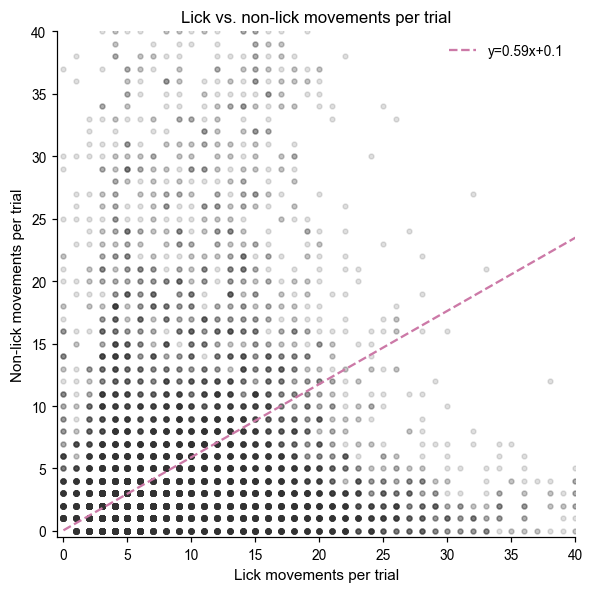

Total movements vs. % non-lick: Pearson r = 0.091, p = 1.83e-28


In [11]:
r, pval = stats.pearsonr(trial_summary["lick_movements"], trial_summary["nonlick_movements"])
print(f"Lick vs. non-lick movements per trial: Pearson r = {r:.3f}, p = {pval:.3g}")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(trial_summary["lick_movements"], trial_summary["nonlick_movements"],
           alpha=0.15, s=10, color=PALETTE["all"])
m, b = np.polyfit(trial_summary["lick_movements"], trial_summary["nonlick_movements"], 1)
xs = np.linspace(0, 40, 50)
ax.plot(xs, m * xs + b, color=PALETTE["accent"], ls="--", label=f"y={m:.2f}x+{b:.1f}")
ax.set(xlabel="Lick movements per trial", ylabel="Non-lick movements per trial",
       xlim=(-0.5, 40), ylim=(-0.5, 40), title="Lick vs. non-lick movements per trial")
ax.legend()
style_ax(ax)
plt.tight_layout()
save_fig(fig, "lick_vs_nonlick_scatter", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

r2, p2 = stats.pearsonr(trial_summary["total_movements"], trial_summary["percent_nonlick"])
print(f"Total movements vs. % non-lick: Pearson r = {r2:.3f}, p = {p2:.3g}")

## 8. Preparatory timing

Does a non-lick movement often occur *before* the trial's cue-response lick — a
candidate signature of covert movement preparation? Uses the pooled
`movement_before_cue_response` column directly, rather than reconstructing it from
`nearest_movement_id` the way the source notebook did (that reconstruction needs the
per-session lick table and is unnecessary here — the pooled parquet already carries the
flag).

In [12]:
valid_trials = df.loc[df["cue_response"] == True, ["session", "trial"]].drop_duplicates()
df_valid = df.merge(valid_trials, on=["session", "trial"], how="inner")

mbcr = df_valid["movement_before_cue_response"].fillna(False).astype(bool)
nonlick_pre_cue = df_valid[(df_valid["has_lick"] == False) & mbcr]

trials_with_nonlick_pre = nonlick_pre_cue.groupby(["session", "trial"]).ngroups
total_trials_with_cue = len(valid_trials)
pct = trials_with_nonlick_pre / total_trials_with_cue * 100
print(f"Trials with >=1 non-lick movement before the cue-response lick: "
      f"{trials_with_nonlick_pre:,} of {total_trials_with_cue:,} ({pct:.1f}%)")

nonlick_pre_counts = nonlick_pre_cue.groupby(["session", "trial"]).size().rename("num_nonlick_pre_cue")
avg_nonlick_pre = nonlick_pre_counts.mean()
print(f"Average number of pre-cue non-lick movements (per trial with a cue response): {avg_nonlick_pre:.2f}")

trials_2plus = (nonlick_pre_counts >= 2).sum()
pct2 = trials_2plus / total_trials_with_cue * 100
print(f"Trials with >=2 non-lick movements before the cue-response lick: "
      f"{trials_2plus:,} of {total_trials_with_cue:,} ({pct2:.1f}%)")

Trials with >=1 non-lick movement before the cue-response lick: 7,138 of 14,149 (50.4%)
Average number of pre-cue non-lick movements (per trial with a cue response): 1.30
Trials with >=2 non-lick movements before the cue-response lick: 1,623 of 14,149 (11.5%)


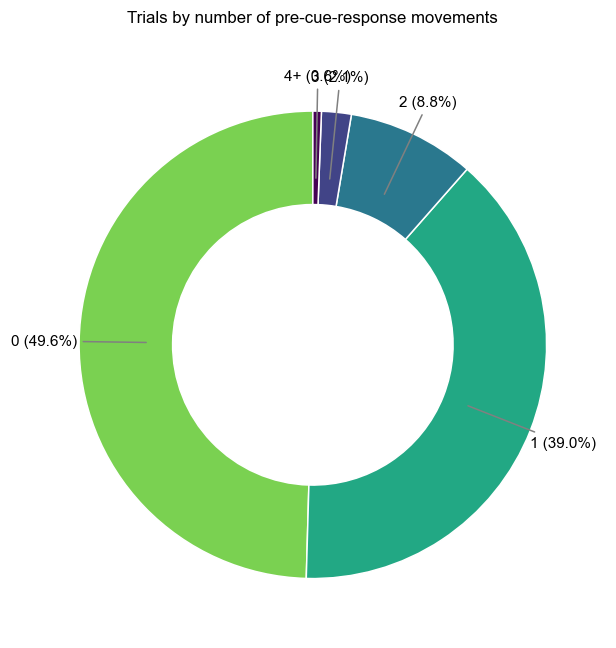

In [13]:
pre_counts = (
    df_valid[df_valid["movement_before_cue_response"] == True]
    .groupby(["session", "trial"]).size()
)
zero_trials = total_trials_with_cue - len(pre_counts)
counts_series = pre_counts.value_counts().sort_index()
counts_series.loc[0] = zero_trials
counts_series = counts_series.sort_index()

# Collapse counts >=4 into "4+", matching cueresponse cell 43
max_count = 4
if counts_series.index.max() > max_count:
    extra = counts_series[counts_series.index >= max_count].sum()
    counts_series = counts_series[counts_series.index < max_count]
    counts_series.loc[max_count] = extra
proportions = counts_series / counts_series.sum()

fig, ax = plt.subplots(figsize=(6, 6))
colors = plt.cm.viridis_r(np.linspace(0.2, 1, len(proportions)))
wedges, _ = ax.pie(proportions, startangle=90, colors=colors,
                    wedgeprops=dict(width=0.4, edgecolor="white"))

for i, (w, prop) in enumerate(zip(wedges, proportions)):
    label_num = proportions.index[i]
    label_str = f"{label_num}+" if label_num == max_count else str(label_num)
    ang = (w.theta2 - w.theta1) / 2.0 + w.theta1
    x, y = np.cos(np.deg2rad(ang)), np.sin(np.deg2rad(ang))
    ax.annotate(f"{label_str} ({prop * 100:.1f}%)", xy=(x * 0.7, y * 0.7),
                xytext=(x * 1.15, y * 1.15), ha="center", va="center",
                arrowprops=dict(arrowstyle="-", color="gray", lw=1))

ax.set_title("Trials by number of pre-cue-response movements", pad=20)
plt.tight_layout()
save_fig(fig, "precue_movement_count_donut", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()